# Activity Analysis

This notebook focuses on understanding the available activity labels and sensor signals before choosing any final prediction method.

In [2]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from mhealth_activity import Recording

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

TRAIN_DIR = Path(r"c:\Users\giaco\Desktop\ETH\Mobile_Health\DATA\data\train")
TEST_DIR = Path(r"c:\Users\giaco\Desktop\ETH\Mobile_Health\DATA\data\test")

ACTIVITY_ORDER = ["standing", "walking", "running", "cycling"]
ACTIVITY_TO_ID = {name: idx for idx, name in enumerate(ACTIVITY_ORDER)}
ID_TO_ACTIVITY = {idx: name for name, idx in ACTIVITY_TO_ID.items()}

TRAIN_DIR, TRAIN_DIR.exists(), TEST_DIR.exists()

(WindowsPath('c:/Users/giaco/Desktop/ETH/Mobile_Health/DATA/data/train'),
 True,
 True)

In [1]:
def normalize_activities(raw_value):
    if isinstance(raw_value, dict):
        labels = [name for name in ACTIVITY_ORDER if bool(raw_value.get(name, False))]
    elif isinstance(raw_value, (list, tuple, set, np.ndarray)):
        parsed = []
        for item in raw_value:
            if isinstance(item, (int, np.integer)) and int(item) in ID_TO_ACTIVITY:
                parsed.append(ID_TO_ACTIVITY[int(item)])
            elif isinstance(item, str):
                label = item.strip().lower()
                if label in ACTIVITY_TO_ID:
                    parsed.append(label)
        labels = [name for name in ACTIVITY_ORDER if name in set(parsed)]
    else:
        labels = []

    return labels


def parse_trace_id(path):
    return int(path.stem.split("_")[-1])


def clean_step_count(value):
    if value is None:
        return np.nan
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value if value >= 0 else np.nan


SENSOR_GROUPS = {
    "watch_acc": ["ax", "ay", "az"],
    "watch_gyr": ["gx", "gy", "gz"],
    "watch_mag": ["mx", "my", "mz"],
    "phone_acc": ["phone_ax", "phone_ay", "phone_az"],
    "phone_gyr": ["phone_gx", "phone_gy", "phone_gz"],
    "phone_linacc": ["phone_lax", "phone_lay", "phone_laz"],
    "environment": ["altitude", "temperature", "phone_pressure", "phone_light"],
}


In [3]:
rows = []
sensor_counter = Counter()
samplerate_rows = []

for path in sorted(TRAIN_DIR.glob("*.pkl")):
    rec = Recording(str(path))
    labels = rec.labels or {}
    activities = normalize_activities(labels.get("activities", []))

    row = {
        "file": path.name,
        "trace_id": parse_trace_id(path),
        "path_idx": labels.get("path_idx"),
        "watch_loc": labels.get("watch_loc"),
        "step_count": clean_step_count(labels.get("step_count")),
        "n_sensors": len(rec.data),
        "duration_s": rec.data["ax"].total_time if "ax" in rec.data else np.nan,
        "activity_combo": " + ".join(activities) if activities else "none",
        "n_activities": len(activities),
    }

    for activity in ACTIVITY_ORDER:
        row[activity] = activity in activities

    rows.append(row)

    for sensor_name, trace in rec.data.items():
        sensor_counter[sensor_name] += 1
        samplerate_rows.append(
            {
                "file": path.name,
                "sensor": sensor_name,
                "samplerate_hz": trace.samplerate,
                "duration_s": trace.total_time,
            }
        )

metadata_df = pd.DataFrame(rows).sort_values("trace_id").reset_index(drop=True)
samplerate_df = pd.DataFrame(samplerate_rows)
sensor_summary_df = (
    pd.Series(sensor_counter, name="count")
    .sort_values(ascending=False)
    .rename_axis("sensor")
    .reset_index()
)

metadata_df["has_step_count"] = metadata_df["step_count"].notna()
metadata_df.head()

,file,trace_id,path_idx,watch_loc,step_count,n_sensors,duration_s,activity_combo,n_activities,standing,walking,running,cycling,has_step_count
0,train_trace_000.pkl,0,0,0,NaN,37,576.042,walking,1,False,True,False,False,False
1,train_trace_001.pkl,1,1,1,NaN,42,788.925,standing + walking,2,True,True,False,False,False
2,train_trace_002.pkl,2,0,2,NaN,41,540.746,walking,1,False,True,False,False,False
3,train_trace_003.pkl,3,2,0,NaN,42,733.139,walking,1,False,True,False,False,False
4,train_trace_004.pkl,4,4,1,1023.0,42,530.442,walking,1,False,True,False,False,True


In [4]:
print(f"Training recordings: {len(metadata_df)}")
print(f"Unique activity combinations: {metadata_df['activity_combo'].nunique()}")
print(f"Recordings with step count available: {int(metadata_df['has_step_count'].sum())}")
print()
print("Number of active labels per recording")
display(metadata_df["n_activities"].value_counts().sort_index().rename("count"))
print()
print("Most frequent activity combinations")
display(metadata_df["activity_combo"].value_counts().head(15).rename("count"))
print()
print("Per-activity counts")
display(metadata_df[ACTIVITY_ORDER].sum().rename("count"))


Training recordings: 396
Unique activity combinations: 10
Recordings with step count available: 33

Number of active labels per recording


n_activities
1    246
2    106
3     41
4      3
Name: count, dtype: int64


Most frequent activity combinations


activity_combo
walking                                   218
standing + walking                         51
walking + running                          33
standing + walking + running               29
walking + cycling                          20
cycling                                    19
standing + walking + cycling               12
running                                     9
standing + walking + running + cycling      3
running + cycling                           2
Name: count, dtype: int64


Per-activity counts


standing     95
walking     366
running      76
cycling      56
Name: count, dtype: int64

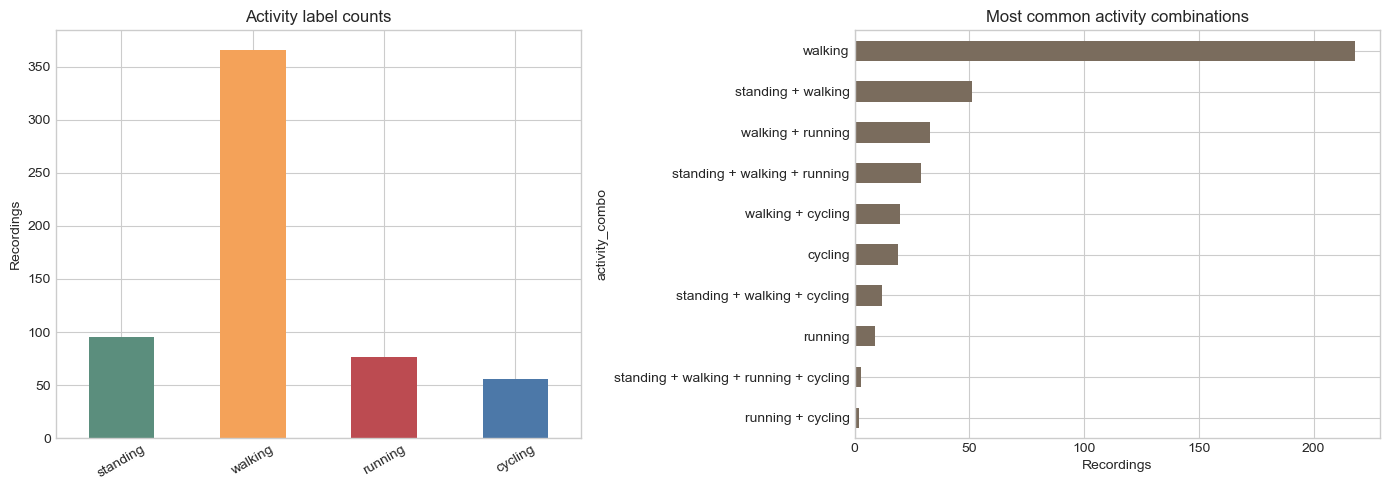

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

activity_counts = metadata_df[ACTIVITY_ORDER].sum().reindex(ACTIVITY_ORDER)
activity_counts.plot(kind="bar", ax=axes[0], color=["#5B8E7D", "#F4A259", "#BC4B51", "#4C78A8"])
axes[0].set_title("Activity label counts")
axes[0].set_ylabel("Recordings")
axes[0].tick_params(axis="x", rotation=30)

combo_counts = metadata_df["activity_combo"].value_counts().head(12).sort_values()
combo_counts.plot(kind="barh", ax=axes[1], color="#7A6C5D")
axes[1].set_title("Most common activity combinations")
axes[1].set_xlabel("Recordings")

plt.tight_layout()
plt.show()

C:\Users\giaco\AppData\Local\Temp\ipykernel_25900\979625654.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(duration_by_activity, labels=ACTIVITY_ORDER)


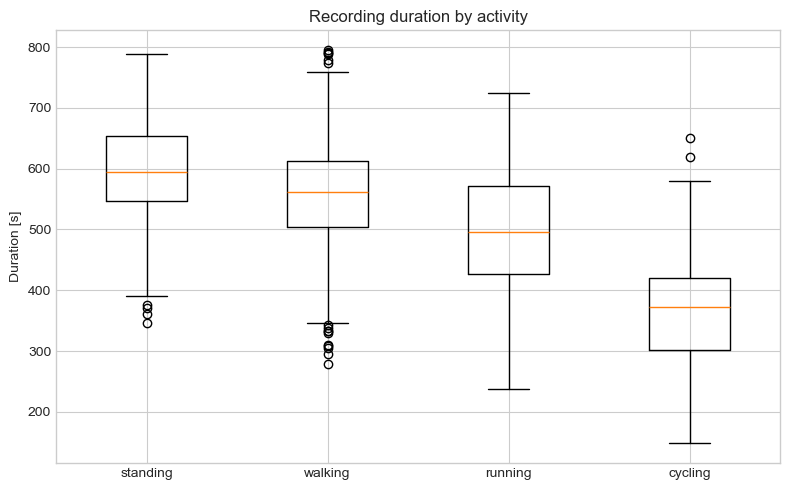

,duration_s,step_count
activity_combo,,
standing + walking,637.5570,1038.5
standing + walking + running + cycling,579.3260,NaN
standing + walking + running,576.6280,NaN
walking,567.6265,1020.5
walking + running,466.6000,936.0
standing + walking + cycling,463.6340,290.0
walking + cycling,385.3290,172.0
running + cycling,376.3505,NaN
running,278.2060,734.0


In [6]:
duration_by_activity = []
for activity in ACTIVITY_ORDER:
    subset = metadata_df.loc[metadata_df[activity], "duration_s"].dropna()
    duration_by_activity.append(subset.values)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(duration_by_activity, labels=ACTIVITY_ORDER)
ax.set_title("Recording duration by activity")
ax.set_ylabel("Duration [s]")
plt.tight_layout()
plt.show()

metadata_df.groupby("activity_combo")[["duration_s", "step_count"]].median().sort_values("duration_s", ascending=False).head(12)

In [7]:
sensor_summary_df.head(20)

,sensor,count
0,phone_mx,396
1,phone_lax,396
2,phone_mz,396
3,phone_rotm,396
4,gx,396
5,packetNumber,396
6,phone_gravz,396
7,phone_gx,396
8,phone_laz,396
9,az,396


In [8]:
samplerate_summary = (
    samplerate_df.groupby("sensor")["samplerate_hz"]
    .agg(["median", "mean", "min", "max"])
    .sort_values("median", ascending=False)
)
samplerate_summary.head(20)

,median,mean,min,max
sensor,,,,
ay,200.021206,199.910985,192.212459,200.439764
az,200.021206,199.910985,192.212459,200.439764
gx,200.021206,199.910985,192.212459,200.439764
gy,200.021206,199.910985,192.212459,200.439764
gz,200.021206,199.910985,192.212459,200.439764
ax,200.021206,199.910985,192.212459,200.439764
phone_magrotz,198.204511,197.709510,50.029811,503.695574
phone_magroty,198.204511,197.709538,50.029811,503.695574
phone_magrotx,198.204511,197.709513,50.029811,503.695574


In [9]:
def plot_recording(file_name, sensor_groups=None, start_s=0, end_s=60):
    if sensor_groups is None:
        sensor_groups = SENSOR_GROUPS

    rec = Recording(str(TRAIN_DIR / file_name))
    labels = normalize_activities((rec.labels or {}).get("activities", []))

    keys = []
    ylabels = []
    legend_labels = []

    for group_name, sensor_names in sensor_groups.items():
        available = [sensor for sensor in sensor_names if sensor in rec.data]
        if not available:
            continue
        keys.append(available)
        ylabels.append(group_name)
        legend_labels.append(available)

    print(file_name)
    print(rec.labels)
    print(f"Normalized activities: {labels}")
    rec.plot(keys, ylabels=ylabels, labels=legend_labels, title=file_name, start_s=start_s, end_s=end_s)


In [12]:
single_label_examples = {}
for activity in ACTIVITY_ORDER:
    subset = metadata_df.loc[(metadata_df[activity]) & (metadata_df["n_activities"] == 1), "file"]
    single_label_examples[activity] = subset.iloc[0] if len(subset) else None

single_label_examples

{'standing': None,
 'walking': 'train_trace_000.pkl',
 'running': 'train_trace_015.pkl',
 'cycling': 'train_trace_006.pkl'}

train_trace_000.pkl
{'path_idx': 0, 'watch_loc': 0, 'step_count': -1, 'activities': {'standing': False, 'walking': True, 'running': False, 'cycling': False}}
Normalized activities: ['walking']


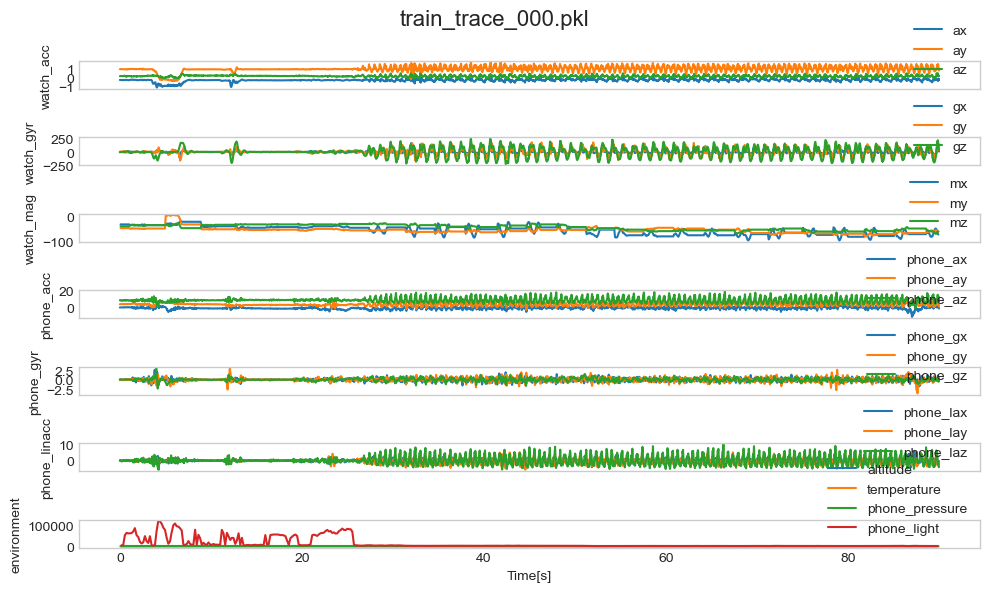

In [13]:
# Change the value below to inspect a different single-label example.
example_activity = "walking"
example_file = single_label_examples[example_activity]
plot_recording(example_file, start_s=0, end_s=90)

train_trace_006.pkl
{'path_idx': 4, 'watch_loc': 0, 'step_count': -1, 'activities': {'standing': False, 'walking': False, 'running': False, 'cycling': True}}
Normalized activities: ['cycling']


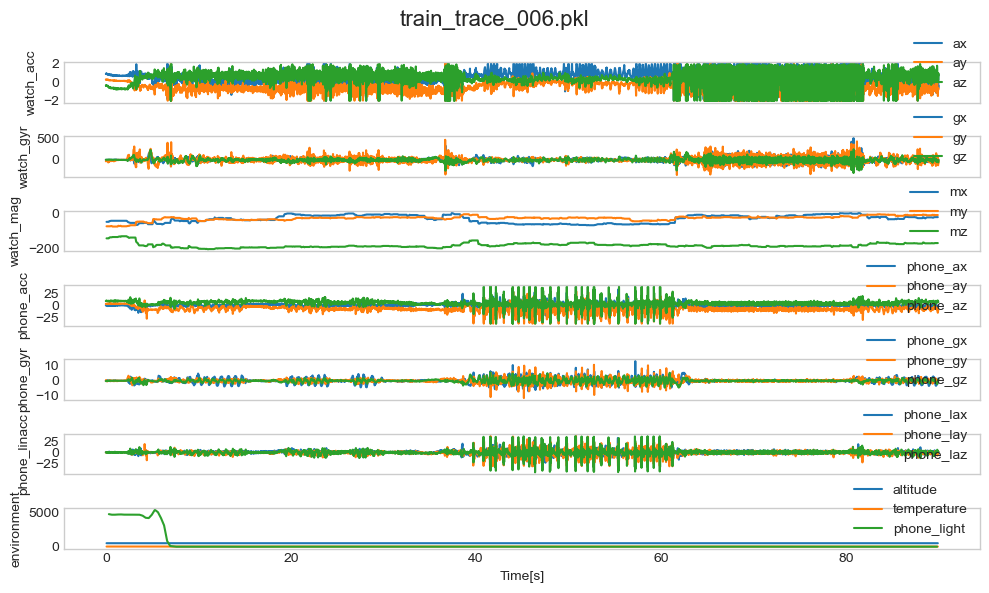

In [16]:
example_activity = "cycling"
example_file = single_label_examples[example_activity]
plot_recording(example_file, start_s=0, end_s=90)

train_trace_015.pkl
{'path_idx': 1, 'watch_loc': 2, 'step_count': 734, 'activities': {'standing': False, 'walking': False, 'running': True, 'cycling': False}}
Normalized activities: ['running']


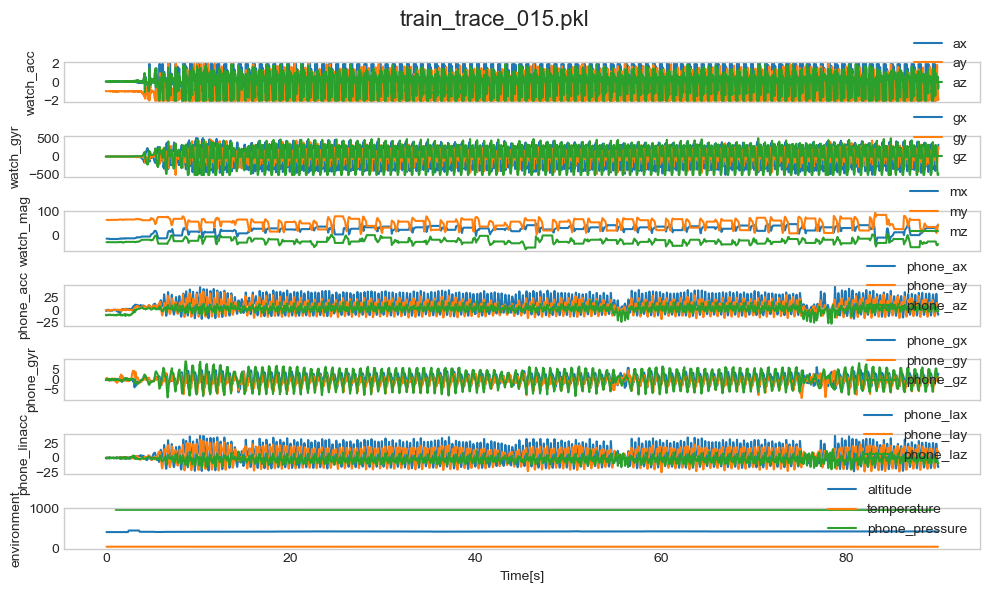

In [17]:
example_activity = "running"
example_file = single_label_examples[example_activity]
plot_recording(example_file, start_s=0, end_s=90)

## Notes for next steps

- The activity target is multi-label, not a single class, so any final estimator should respect that.
- The labels are stored in mixed formats, so `normalize_activities(...)` should be reused anywhere else in the project.
- The plotting helper is meant for manual inspection first; once we understand the separability better, we can decide whether a rule-based or ML-based approach is worth it.